In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df=pd.read_excel("HousePricePrediction.xlsx")

In [9]:
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [10]:
df.tail()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN
2918,2918,60,RL,9627,Inside,1Fam,5,1993,1994,HdBoard,0.0,996.0,NaN


In [11]:
df.shape


(2919, 13)

In [12]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2',
       'TotalBsmtSF', 'SalePrice'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [14]:
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [15]:
df.isna().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [16]:
object_cols=df.select_dtypes(include=['object']).columns
object_cols


Index(['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st'], dtype='object')

In [17]:
int_cols=df.select_dtypes(include=['int64']).columns
int_cols

Index(['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt',
       'YearRemodAdd'],
      dtype='object')

In [18]:
float_cols=df.select_dtypes(include=['float64']).columns
float_cols

Index(['BsmtFinSF2', 'TotalBsmtSF', 'SalePrice'], dtype='object')

In [19]:
print("object cols" , len(object_cols))

object cols 4


In [20]:
print("int cols",len(int_cols))

int cols 6


In [21]:
print("float cols",len(float_cols))

float cols 3


# Exploratory Data Analysis

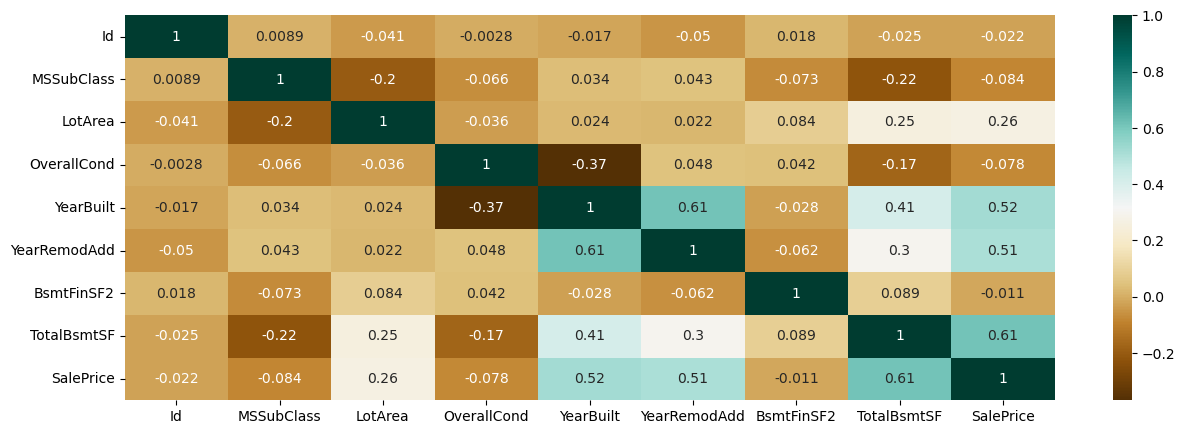

In [22]:
num_data=df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(15,5))
sns.heatmap(num_data.corr(),annot=True,cmap="BrBG")
plt.show()


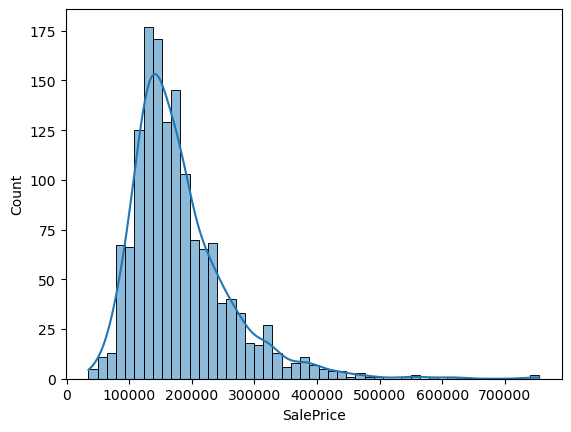

In [23]:
sns.histplot(df['SalePrice'],kde=True)
plt.show()

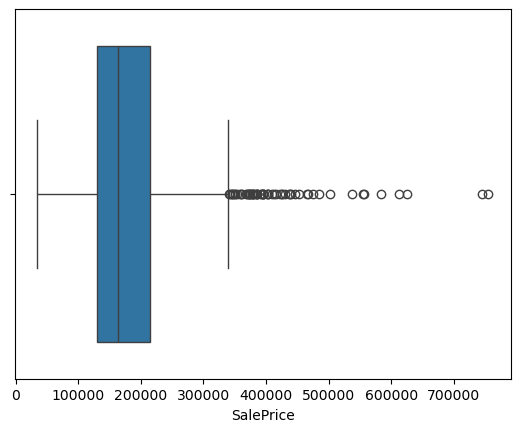

In [24]:
sns.boxplot(x=df['SalePrice'])
plt.show()

# Categorical feature analysis

In [25]:
for col in object_cols:
    print(col,";",df[col].nunique())

MSZoning ; 5
LotConfig ; 5
BldgType ; 5
Exterior1st ; 15


In [26]:
df['Exterior1st'].value_counts().head(5)

Exterior1st
VinylSd    1025
MetalSd     450
HdBoard     442
Wd Sdng     411
Plywood     221
Name: count, dtype: int64

In [27]:
df.drop('Id',axis=1,inplace=True)

In [28]:
df['SalePrice'].isnull().sum()

np.int64(1459)

In [29]:
df['SalePrice'].fillna(df['SalePrice'].mean())

0       208500.00000
1       181500.00000
2       223500.00000
3       140000.00000
4       250000.00000
            ...     
2914    180921.19589
2915    180921.19589
2916    180921.19589
2917    180921.19589
2918    180921.19589
Name: SalePrice, Length: 2919, dtype: float64

In [30]:
df=df.dropna()

In [31]:
df.shape

(1460, 12)

In [32]:
df['MSSubClass'].nunique()

15

In [36]:
MSSubClass_price=df.groupby('MSSubClass')['SalePrice'].mean()


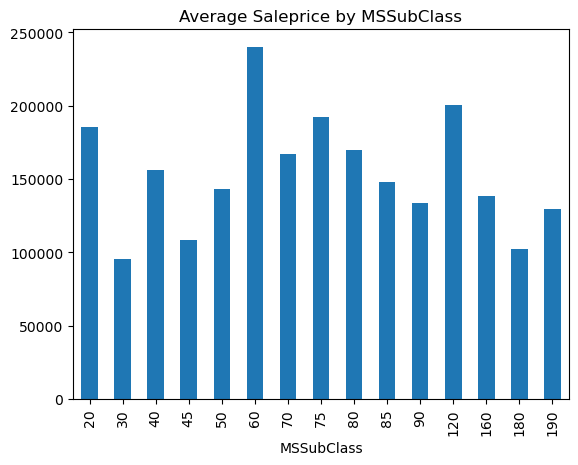

In [40]:
MSSubClass_price.plot(kind="bar")
plt.title("Average Saleprice by MSSubClass")
plt.show()

In [41]:
df['MSZoning'].nunique()

5

In [42]:
df['MSZoning'].unique()

array(['RL', 'RM', 'C (all)', 'FV', 'RH'], dtype=object)

In [46]:
MSZoningvsPrice=df.groupby('MSZoning')['SalePrice'].mean()

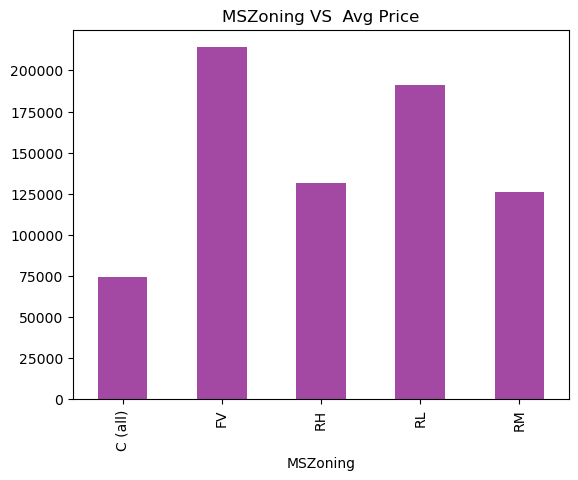

In [47]:
MSZoningvsPrice.plot(kind='bar',color='#A349A4')
plt.title("MSZoning VS  Avg Price")
plt.show()

In [48]:
df['LotConfig'].unique()

array(['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3'], dtype=object)

In [52]:
df['LotConfig'].nunique()

5

In [53]:
df['BldgType'].nunique()

5

In [54]:
df['BldgType'].unique()

array(['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs'], dtype=object)

# OneHotEncoding

In [56]:
from sklearn.preprocessing import OneHotEncoder

In [57]:
object_cols

Index(['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st'], dtype='object')

In [58]:
encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=False)

In [60]:
# handle_unknown='ignore'  (use krnne wen aluth category awath error nowenn)
#sparse_output=False (normal numpy array ekk return krnn)

In [62]:
encoded=pd.DataFrame(encoder.fit_transform(df[object_cols]))

In [64]:
encoded.index=df.index #original dataset eke rows ekk match krnw.ntnm mix wenw 

In [65]:
encoded.columns=encoder.get_feature_names_out()
#columns names clear krnw

In [66]:
final_df=df.drop(object_cols,axis=1
                )

In [67]:
final_df=pd.concat([final_df,encoded],axis=1)

In [68]:
print("Final columns:",final_df.shape)

Final columns: (1460, 38)


In [69]:
final_df.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_C (all),MSZoning_FV,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,60,8450,5,2003,2003,0.0,856.0,208500.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,20,9600,8,1976,1976,0.0,1262.0,181500.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,60,11250,5,2001,2002,0.0,920.0,223500.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,70,9550,5,1915,1970,0.0,756.0,140000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,60,14260,5,2000,2000,0.0,1145.0,250000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [70]:
final_df['SalePrice']

0       208500.0
1       181500.0
2       223500.0
3       140000.0
4       250000.0
          ...   
1455    175000.0
1456    210000.0
1457    266500.0
1458    142125.0
1459    147500.0
Name: SalePrice, Length: 1460, dtype: float64

# Train Test Split

In [71]:
from sklearn.model_selection import train_test_split

In [73]:
x=final_df.drop('SalePrice',axis=1)
y=final_df['SalePrice']

In [74]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
# hemdama same shuflle order use krnw random  state

In [75]:
x_train.shape

(1168, 37)

In [76]:
y_train.shape

(1168,)

In [77]:
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import svm

# SVM

In [78]:
model1= svm.SVR()

In [80]:
model1.fit(x_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [81]:
pred1=model1.predict(x_test)

In [82]:
print("SVM MAPE",mean_absolute_percentage_error(y_test,pred1))

SVM MAPE 0.35966348625875183


# RandomForestRegressor

In [87]:
model2=RandomForestRegressor()

In [88]:
model2.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [89]:
pred2=model2.predict(x_test)

In [90]:
print("RF MAPE :", mean_absolute_percentage_error(y_test,pred2))

RF MAPE : 0.13968646905230514


# Linear Regreesion

In [91]:
model3=LinearRegression()
model3.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [92]:
pred3=model3.predict(x_test)

In [94]:
print("LR MAPE:", mean_absolute_percentage_error(y_test, pred3))

LR MAPE: 0.19782882652025133


In [97]:
sample_pred=model2.predict(x_test[0:5])

In [98]:
sample_pred

array([151466.75, 272968.82, 129932.25, 132678.  , 281111.48])